# EPIMETHEUS - Working Example

This notebook demonstrates the complete workflow for building an effective PSF (ePSF) from astronomical images using $\texttt{EPIMETHEUS}$ (Effective Psf Inferred from Mosaics using an Estimation Technique for Heterogeneous Exposures to get a Unique PSF over the Sensor field). See Benotto et al. 2026 for further details. 

In this example a single calibrated (_cal.fits) image of Omega Centauri is used.

**Overview:**
 1. Define images and load the fits files
 2. Source extraction and star selection
 3. Extract and process star cutouts
 4. Build the ePSF

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import AsinhNorm
from tqdm import tqdm

import epimetheus as epi

SExtractor found: /usr/bin/source-extractor (Source Extractor version 2.25.0 (2018-02-08))


### Download

The following cell downloads the data used in this example notebook

In [ ]:
from astroquery.mast import Observations


# DOWNLOAD Niriss F140M cal file of Omega Centauri.
# Collection: JWSTI nstrument: NIRISS/IMAGE
# Filters: CLEAR;F140M
# Obs ID: jw05110-o001_t001_niriss_clear-f140m
# Proposal PI: Bedin, Luigi R.
# Proposal ID: 5110

Observations.download_file(
    "mast:JWST/product/jw05110001001_02201_00012_nis_cal.fits",
    local_path="./img.fits",
)

INFO: Found cached file ./img.fits with expected size 117570240. [astroquery.query]


('COMPLETE', None, None)

The following cell loads all images into a collection. The code automatically reads key parameters from the FITS headers and compute the others when possible (AB zeropoint, pixel scale, etc.). If a parameter cannot be automatically determined, it can be passed manually to the Image constructor. The `variance_type` parameter specifies how the error map is stored:
- `"rms"` for root-mean-square error maps
- `"var"` for variance maps  
- `"weight"` for inverse-variance weight maps

In [7]:

images_info = {
    "img": {
        "data_filepath": "./img.fits",
        "err_filepath": "./img.fits"
    },
}
filter_name = "F115WN"




##################

image_collection = epi.ImagesCollection()

field_names = list(images_info.keys())
for field_name in field_names:
    im = epi.Image(
        image_path=images_info[field_name]["data_filepath"],
        variance_path=images_info[field_name]["err_filepath"],
        image_ext="SCI",
        variance_ext="ERR",
        variance_type="rms",
    )
    image_collection.add_image(im, field_name)

print(image_collection)

property      | img           
--------------+---------------
image path    | img.fits      
AB zeropoint  | 26.40         
pixel scale   | 0.06532 arcsec
variance type | rms           



Set DATE-AVG to '2024-08-08T01:08:16.283' from MJD-AVG.
Set DATE-END to '2024-08-08T01:16:14.070' from MJD-END'. [astropy.wcs.wcs]
Set OBSGEO-B to   -28.053615 from OBSGEO-[XYZ].
Set OBSGEO-H to 1605478665.108 from OBSGEO-[XYZ]'. [astropy.wcs.wcs]


## 3. Source Extraction and Star Selection

This section runs $\texttt{SExtractor}$ to detect sources, then selects point sources (stars) based on aperture flux ratios. Point sources have a characteristic ratio between fluxes measured in narrow and wide apertures, which differs from extended sources.

Define the aperture diameters (in arcseconds) used for the flux ratio calculation.

### Test on the first image

Before processing all images, run the selection on one image to tune the parameters. The diagnostic plot shows the aperture flux ratio vs. magnitude, where stars form a horizontal sequence at a characteristic ratio value.

By default, the first image is used for tuning. Set `force_rerun=True` to re-run SExtractor even if a cached catalogue exists.

Creating clean copy of image


100%|██████████| 3/3 [00:00<00:00, 127.67it/s]


Creating clean copy of rms image


100%|██████████| 3/3 [00:00<00:00, 253.54it/s]


Calling Sextractor
Running SExtractor on ./img.fits...
  Using weight image: ./img.fits (MAP_RMS)
Catalogue saved to: ./epi/stars/F115WN_img.cat
Detected 4916 sources


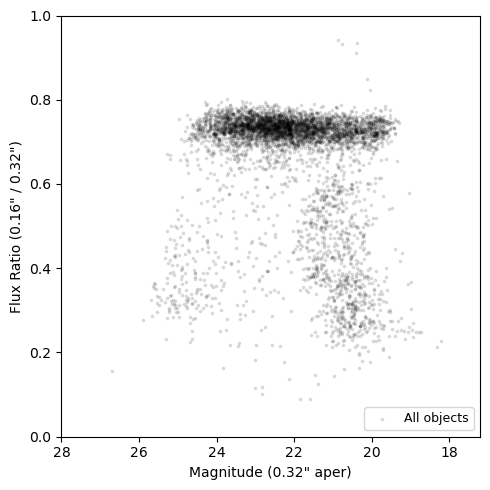

In [8]:
# Aperture diameters in arcsec: (narrow, wide)
APERTURES = np.array((0.16, 0.32))

field_name = field_names[0]

selector = epi.StarSelector(
    image=image_collection[field_name],
    apertures=APERTURES,
    config_overrides={},          # Optional: override SExtractor config parameters
    params_overrides={},          # Optional: override SExtractor output parameters
    star_cat_filename=f"{filter_name}_{field_name}"
)

catalogue = selector.run_sextractor(force_rerun=True)
print(f"Detected {len(catalogue)} sources")

selector.plot_diagnostic(mag_lim=28)

Based on the diagnostic plot above, set the selection parameters:

- **EXPECTED_RATIO**: The aperture flux ratio for point sources (as read from the horizontal sequence in the plot)
- **RATIO_TOLERANCE**: Half-width of the selection band around the expected ratio
- **MAG_LIMIT**: Faint magnitude limit to avoid noisy sources

**Adjust these values to match the stellar locus in your diagnostic plot.**

Inside this box a k-sigma rejection algorithm will be used to reject possible outliers

Apply the selection criteria and visualize the results. Selected stars are highlighted in the updated diagnostic plot.

Star selection: expected ratio = 0.7300, obtained ratio = 0.7281
Selected 1312 stars
Diagnostic plot saved to: ./epi/stars/F115WN_img_diagnostic.pdf


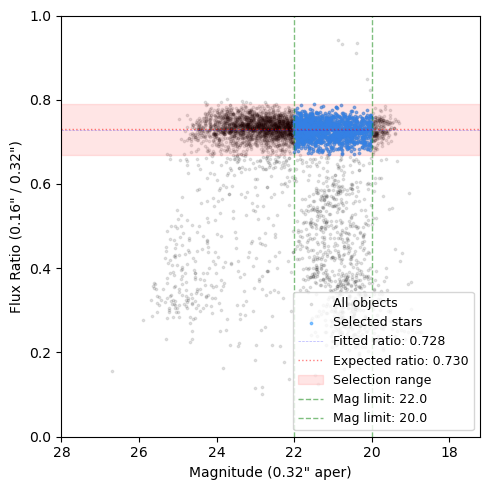

Star catalogue saved to: ./epi/stars/F115WN_img_stars.cat
Selected 1312 stars


In [14]:
EXPECTED_RATIO = 0.73
RATIO_TOLERANCE = 0.06
MAG_LIMIT_MAX = 22.0
MAG_LIMIT_MIN = 20

#######################

selector.select_stars(
    expected_ratio=EXPECTED_RATIO,
    ratio_tolerance=RATIO_TOLERANCE,
    mag_limit=MAG_LIMIT_MAX,
    mag_bright_limit = MAG_LIMIT_MIN
)

selector.plot_diagnostic(mag_lim=28, show=True, save=True)
selector.save_star_catalogue()

print(f"Selected {len(selector.cat_stars)} stars")

### Process All Images

Apply the tuned selection parameters to all images. The catalogues are saved for later use. In this example only one image is loaded, so this passage is not doing anything

In [15]:
star_catalogues = {}

for field_name in field_names:
    selector = epi.StarSelector(
        image=image_collection.data[field_name],
        apertures=APERTURES,
        config_overrides={},
        params_overrides={},
        star_cat_filename=f"{filter_name}_{field_name}"
    )

    selector.run_sextractor(force_rerun=False)
    selector.select_stars(
        expected_ratio=EXPECTED_RATIO,
        ratio_tolerance=RATIO_TOLERANCE,
        mag_limit=MAG_LIMIT_MAX,
        mag_bright_limit = MAG_LIMIT_MIN
    )
    selector.plot_diagnostic(mag_lim=28, show=False, save=True)
    selector.save_star_catalogue()

    star_catalogues[field_name] = selector.cat_stars
    print(f"{field_name}: {len(selector.cat_stars)} stars\n")

Loading existing catalogue: ./epi/stars/F115WN_img.cat
Star selection: expected ratio = 0.7300, obtained ratio = 0.7281
Selected 1312 stars
Diagnostic plot saved to: ./epi/stars/F115WN_img_diagnostic.pdf
Star catalogue saved to: ./epi/stars/F115WN_img_stars.cat
img: 1312 stars



### Merge Catalogues

Wrap the image in a mergedCatalogue object. No star duplication is performed as we are loading a single image

In [17]:
merged_catalogue = epi.MergedCatalogue(
    star_catalogues,
    duplicate_radius=None,
    sort_by_mag=True,
    mag_column="MAG_APER_1"
)

Building Master Catalog...
  Loaded 1312 stars from 1th catalogue
Total stars before duplicate removal: 1312
  Aperture flux ratio: median = 0.7288, std = 0.0218


## 4. Extract and process star cutouts

This section extracts postage stamp cutouts around each star and processes them for ePSF construction.

Define the ePSF parameters:
- **EPSF_NAME**: Identifier for caching intermediate results
- **CUTOUT_SHAPE**: Working size of the cutouts (pixels). Should be large enough to capture the full PSF including large regions free from diffraction spikes to compute the background.
- **OUTPUT_SHAPE**: Final ePSF size (pixels). Should be smaller than cutouts shape to avoid edge effects on the final ePSF due to the shift and stack procedure

In [47]:
EPSF_NAME = filter_name

UPSAMPLE_FACTOR = 2

CUTOUT_SHAPE = np.asarray((85,85))  # Working size (pixels) in NOT upsampled space
OUTPUT_SHAPE = np.asarray((41, 41))  # Final output size (pixels) in NOT upsampled space. So the real output will be this size * UPSAMPLED_FACTOR

Initialize the `StarCutouts` object, which manages the extraction and processing of all star cutouts.

In [48]:
cutouts = epi.StarCutouts(
    merged_catalogue,
    image_collection,
    name=EPSF_NAME,
    cutout_shape=CUTOUT_SHAPE,
    upsample_factor=UPSAMPLE_FACTOR
)

The ePSF will be computed at the ePSF final resolution of 0.03266 "/px
Loading cached catalogue: ./epi/epsf_cat/F115WN.cat
Loaded 1312/1312 stars from saved catalogue


### Process All Stars

Extract all stars

In [ ]:
cutouts.extract_all_cutouts(force_extraction=False, extract_invalid_stars=False)
cutouts.subtract_background_all()

cutouts.summary()
cutouts.save_catalogue()

  0%|          | 0/1312 [00:00<?, ?it/s]

100%|██████████| 1312/1312 [00:00<00:00, 5717.70it/s]

StarCutouts Summary:
  Total stars in catalogue: 1312
  Cutouts extracted: 1312 (100.0%)
  Valid stars: 34 (2.6%)
  Not yet checked stars: 105 (8.0%)
  Stars with shift computed: 0
  Stars with rotation computed: 0
Catalogue saved: ./epi/epsf_cat/F115WN.cat (1312 stars)


'./epi/epsf_cat/F115WN.cat'

**NORM_APERTURE**: Radius of the circular aperture (in arcseconds) used for flux normalization.

The following cell processes each star through the pipeline:
1. Compute centroid shift (Gaussian fit)
2. Align each star
3. Normalize flux


At the end, save the catalogue with all quality flags.


In [57]:
NORM_APERTURE = 0.1 # arcsec

for star_index in tqdm(range(len(cutouts.stars))):

    cutouts.compute_shift_gaussian(star_index, force_recomputation=False)

    cutouts.align_and_rotate_star(star_index, fine_rotation=False)

    cutouts.normalize_star(star_index, NORM_APERTURE)

print(f"Still valid stars: {len(cutouts.stars) - len(cutouts.get_invalid_stars())}")

cutouts.save_catalogue()

100%|██████████| 1312/1312 [00:00<00:00, 3270.00it/s]


Still valid stars: 34
Catalogue saved: ./epi/epsf_cat/F115WN.cat (1312 stars)


'./epi/epsf_cat/F115WN.cat'

### Visual Review

Manually inspect the processed stars to identify and reject any remaining problematic cases (artifacts, nearby bright sources, cosmic rays, etherogeneous background, ...).

**Interactive controls:**
- **Good**: Accept the star for ePSF construction
- **Bad**: Reject the star
- **Back**: Return to the previous star, to change its state
- **Finish**: End the review session


Stars rejected due to the aperture ratio or rotation angle are not shown here. The manual selection is saved to a file every few steps; therefore, rerunning this cell may yield no results if all stars have already been validated.

In [58]:
reviewer = epi.StarReviewer(cutouts)
reviewer.run()

No stars to review.


#### IMPORTANT: Only a small number of stars (34) has ben manually selected as good in this example, so the following results are suboptimal

## 5. Build the ePSF

This section iteratively refines the star positions by fitting each star against the stacked ePSF, then generates the final ePSF at each image most common position angle.

**You can modify:**
- **n_iterations**: Maximum number of refinement iterations
- **rejection_mode**: `'mad'` (median absolute deviation), `'weighted'`, or `'none'`
- **k_sigma**: Sigma threshold for outlier rejection
- **convergence_threshold**: Stop when RMS shift correction falls below this value (pixels)



The convergence plots results figure show:

1. **Top-left**: RMS of shift corrections per iteration (should decrease and stabilize)
2. **Top-right**: Final star centers
3. **Bottom-left**: Scatter plot of shift corrections at each iteration
4. **Bottom-right**: Distribution of shift correction magnitudes

A well-converged solution shows small, randomly distributed corrections centered near zero.


Starting iterative shift refinement
  Valid stars: 34
  Max iterations: 6
  Rejection: mad, k_sigma=3.0
  Recenter ePSF: True
  Convergence threshold: 0.02 px
  Iter 1: rejected 93892 pixel-contribution(s)
  Iter 2: rejected 20612 pixel-contribution(s)
  Initial ePSF recentered by: (0.1855, 0.0465) px
  Initial FWHM: 2.948 px

--- Iteration 1/6 ---


Fitting shifts: 100%|██████████| 34/34 [00:00<00:00, 72.11it/s]


Updating elaborated cutouts...
  Iter 1: rejected 94687 pixel-contribution(s)
  Iter 2: rejected 20986 pixel-contribution(s)
  ePSF recentered by: (-0.0339, 0.0483) px
  ePSF FWHM: 3.092 px
  RMS correction: 0.1922 px
  Max correction: 0.9977 px
  Mean shift: (0.0463, 0.0912) px

--- Iteration 2/6 ---


Fitting shifts: 100%|██████████| 34/34 [00:00<00:00, 74.13it/s]


Updating elaborated cutouts...
  Iter 1: rejected 94784 pixel-contribution(s)
  Iter 2: rejected 21070 pixel-contribution(s)
  ePSF recentered by: (-0.0086, -0.0041) px
  ePSF FWHM: 3.025 px
  RMS correction: 0.0229 px
  Max correction: 0.0489 px
  Mean shift: (0.0579, 0.0696) px

--- Iteration 3/6 ---


Fitting shifts: 100%|██████████| 34/34 [00:00<00:00, 75.20it/s]


Updating elaborated cutouts...
  Iter 1: rejected 94845 pixel-contribution(s)
  Iter 2: rejected 21033 pixel-contribution(s)
  ePSF recentered by: (0.0014, 0.0013) px
  ePSF FWHM: 3.028 px
  RMS correction: 0.0043 px
  Max correction: 0.0081 px
  Mean shift: (0.0606, 0.0743) px

✓ Converged after 3 iterations

Refinement complete: 3 iterations
Converged: True


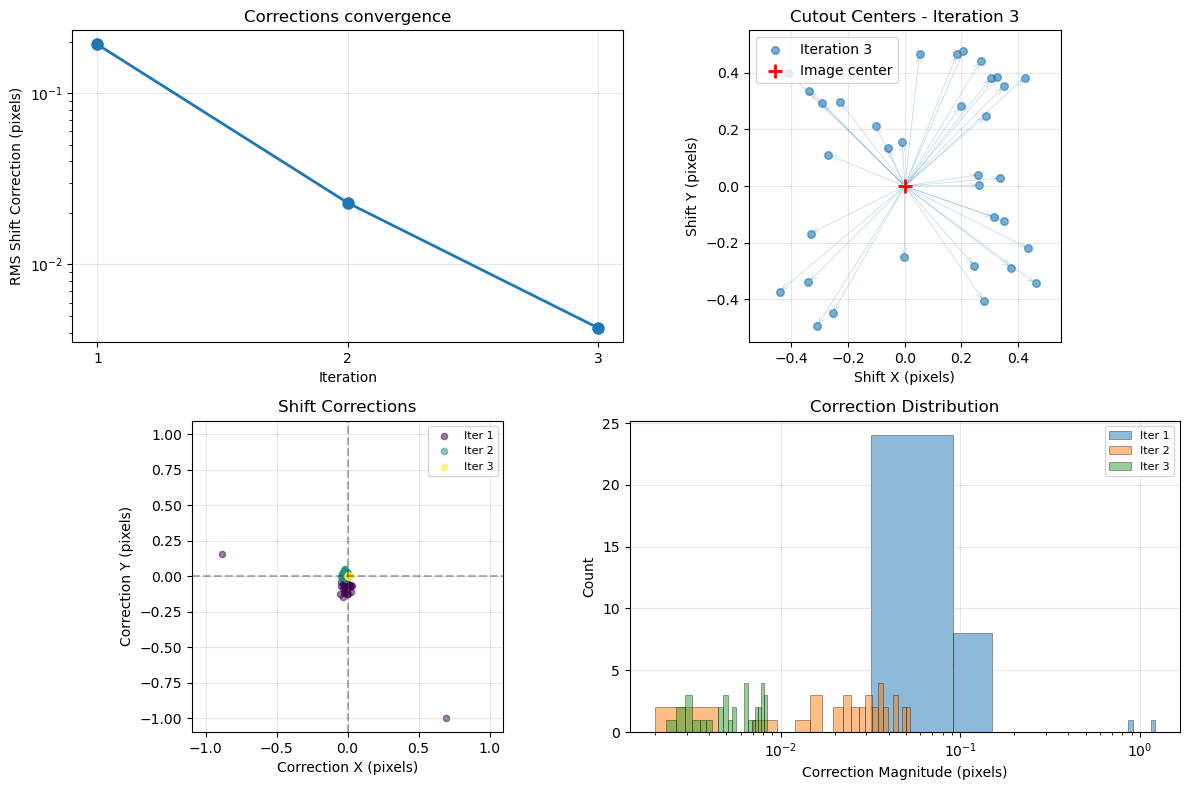

In [64]:
builder = epi.EPIBuilder(cutouts, norm_radius=NORM_APERTURE, pixfrac=0.6)

result = builder.refine_shifts(
    n_iterations=6,
    rejection_mode="mad",
    k_sigma=3.0,
    convergence_threshold=2e-2,
    recenter_epsf=True,
    remove_background=True,
    normalize=True,
    verbose=True
)

builder.plot_convergence_results()

### Generate Final ePSFs

Generate ePSFs for each mosaic using the most common position angle as rotation. The ePSF can be rotated to any desired orientation: here we create one for each mosaic most coomon PA, plus a reference ePSF at PA=0°.

The `angles` dictionary maps output names to position angles (in degrees). You can add any angles you need.

Building multi-angle ePSF
  Angles: ['angle_0']
  Valid stars: 34
  Output shape: (np.int64(82), np.int64(82))

--- angle_0 (PA = 0.0°) ---
  Iter 1: rejected 94841 pixel-contribution(s)
  Iter 2: rejected 21047 pixel-contribution(s)
  FWHM: 3.028 px
  Shape: (82, 82)

Saved 1 ePSF sets to ./epi/output_psf/


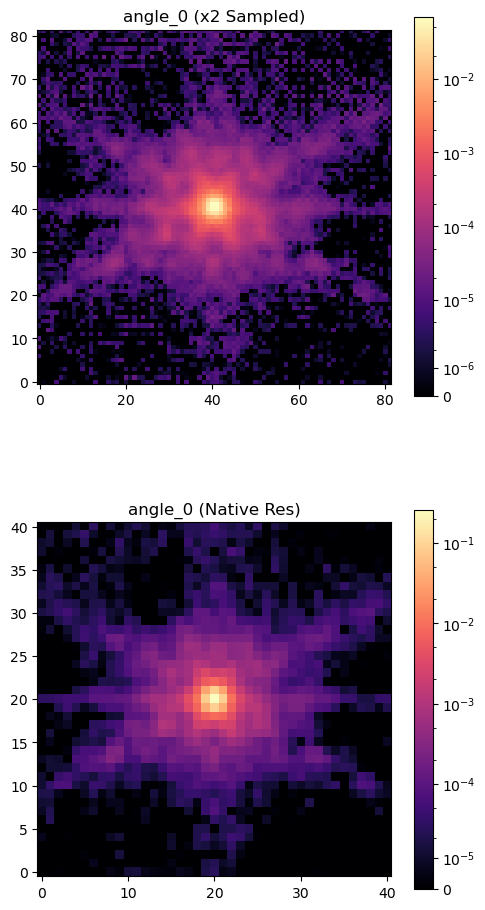


Generated 1 ePSFs


In [65]:
builder.build_multi_angle_epsf(
    output_shape=OUTPUT_SHAPE,
    rejection_mode='mad',
    k_sigma=3.0,
    fine_rotation=False,
    normalize=True,
    verbose=True,
    show_plots=True,
    save_fits=True
);

#### Display q_fit and sharpness of the ePSF

Extracting the cutout for each star


100%|██████████| 1312/1312 [00:02<00:00, 616.32it/s]


FWHM 3.027947191495107
Fitting...


100%|██████████| 1312/1312 [00:19<00:00, 66.68it/s]


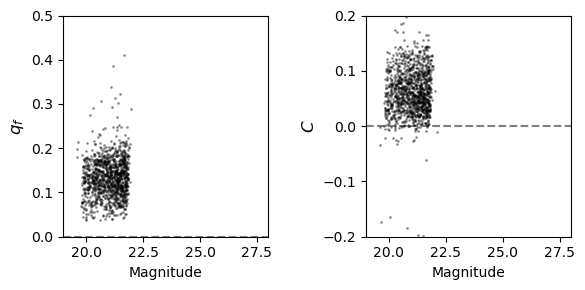

In [66]:
mags, q_fit, sharpness = builder.get_fit_statistics(qFit_region_size = 5)

fig, (ax1,ax2) = plt.subplots(1,2,figsize=(6,3),sharex=True)
ax1.scatter(mags, q_fit, c="k", marker=".", s=5,alpha = 0.3)
ax1.set_ylabel(r"$q_f$",fontsize=12)
ax1.set_xlabel("Magnitude")
ax1.axhline(c="k",alpha=0.5,ls="--")
ax1.set_ylim(0,0.5)
ax1.set_xlim(19,28)

ax2.scatter(mags, sharpness, c="k",marker=".", s=5, alpha=0.3)
ax2.set_ylabel(r"$C$",fontsize=12)
ax2.set_xlabel("Magnitude")
ax2.axhline(c="k",alpha=0.5,ls="--")
ax2.set_ylim(-0.2,0.2)
ax2.set_xlim(19,28)
plt.tight_layout()

plt.show()

Display the rejected zones of each used cutout while stacking

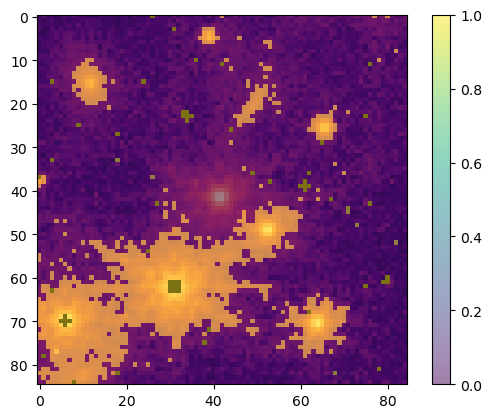

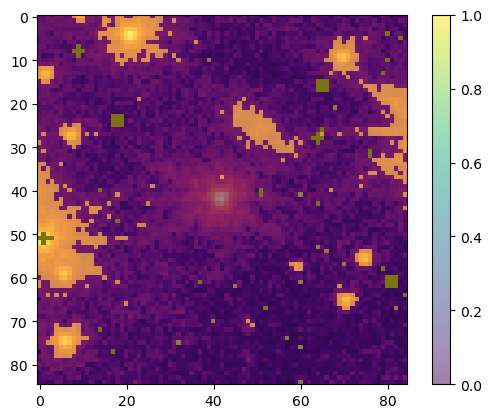

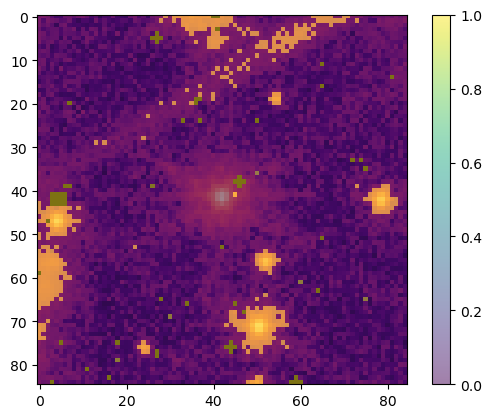

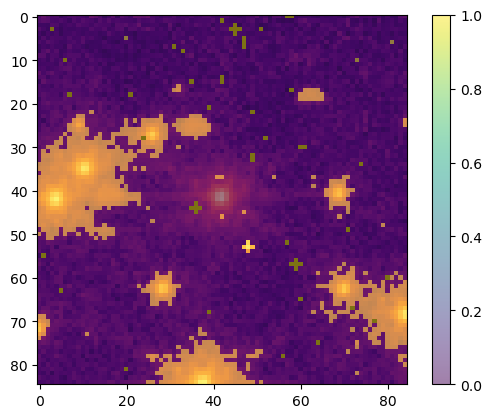

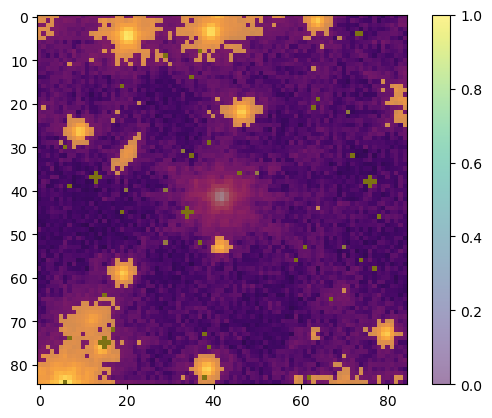

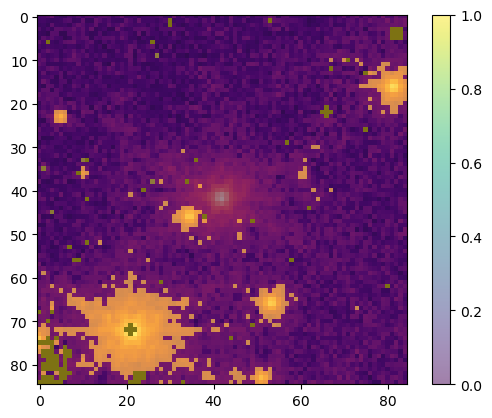

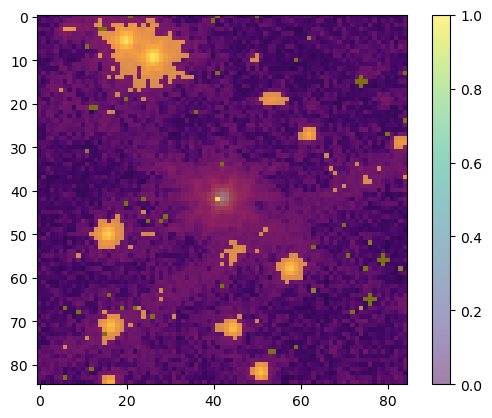

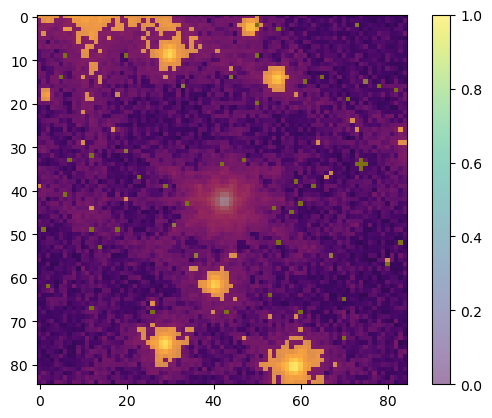

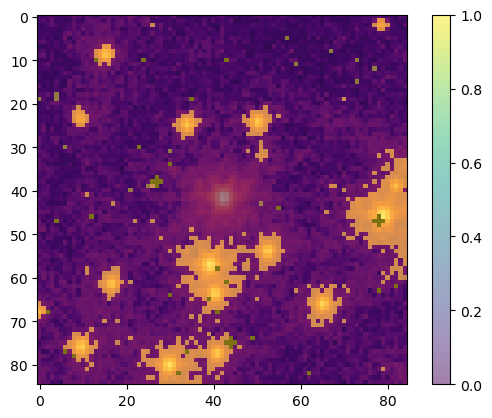

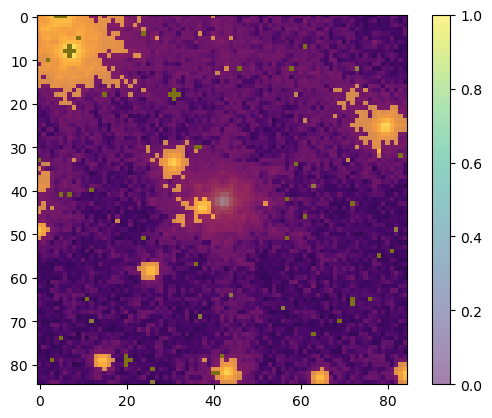

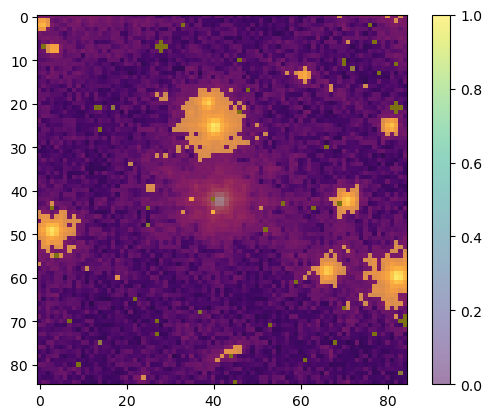

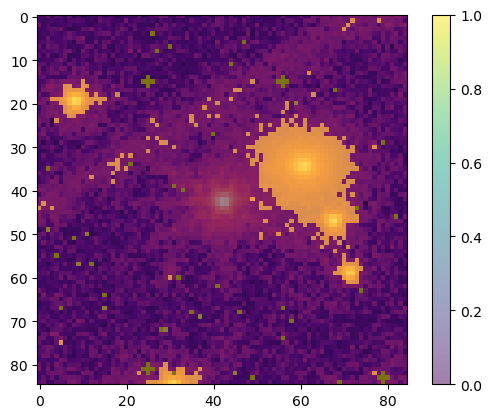

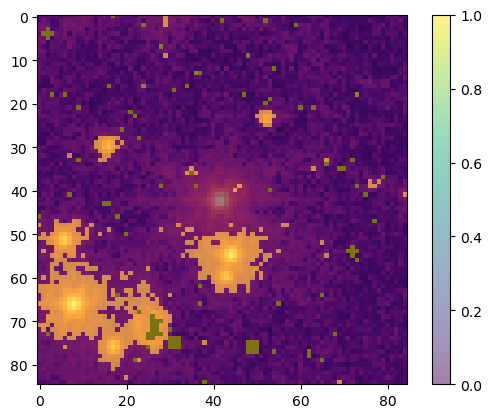

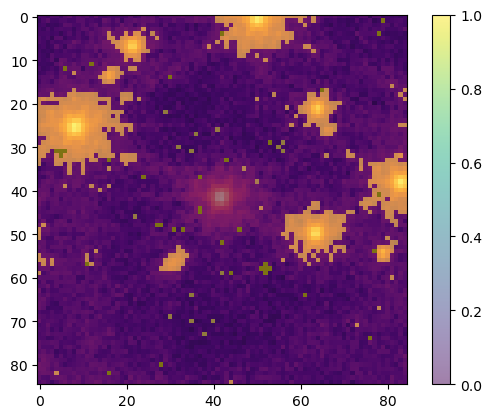

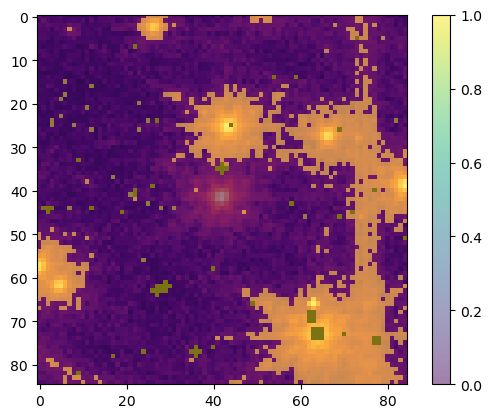

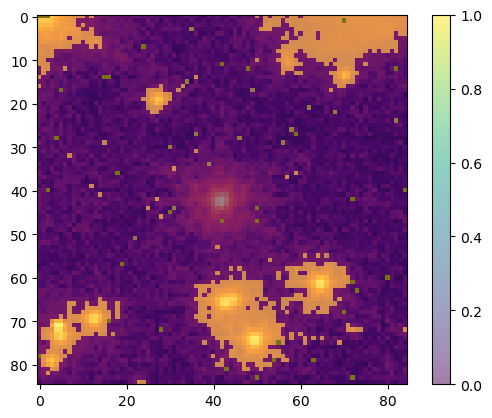

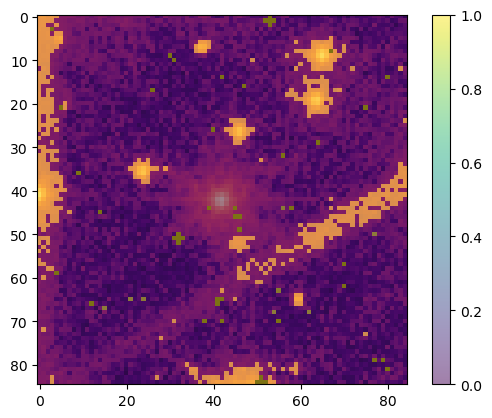

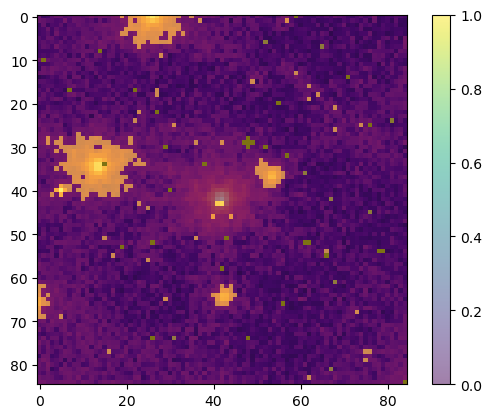

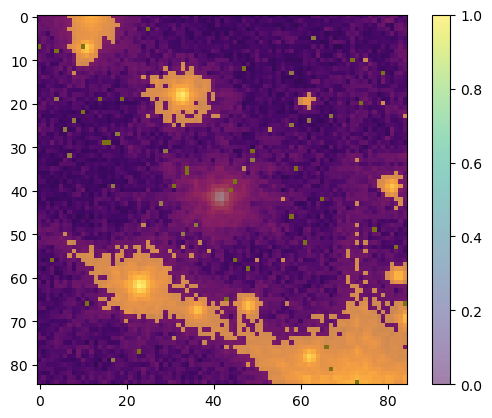

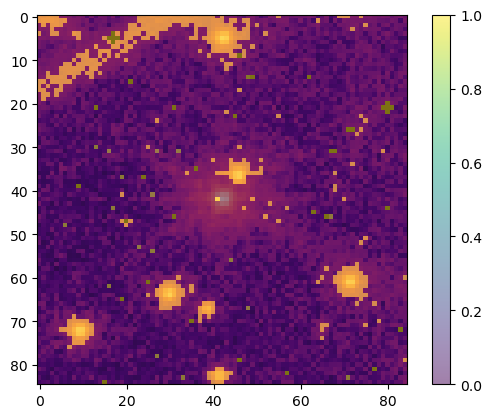

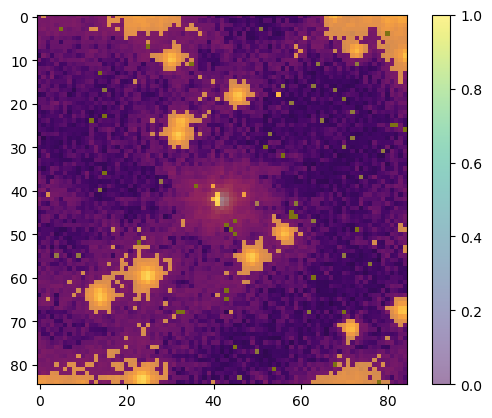

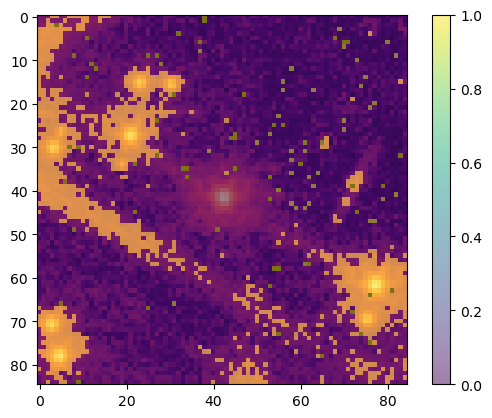

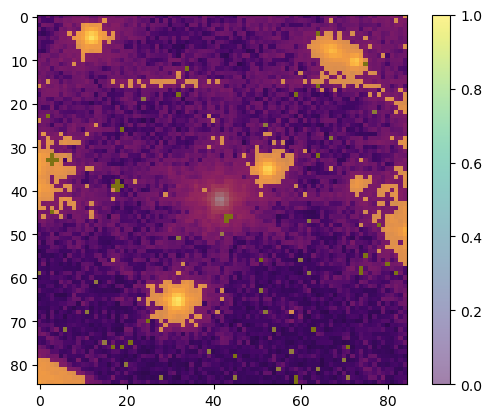

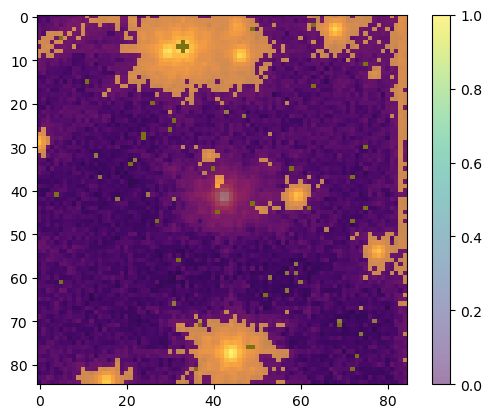

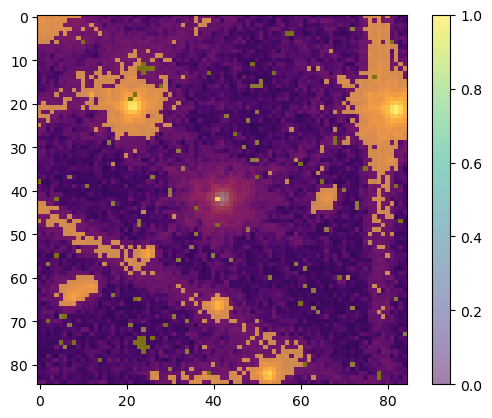

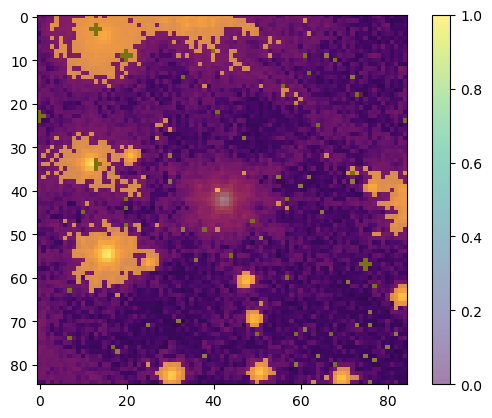

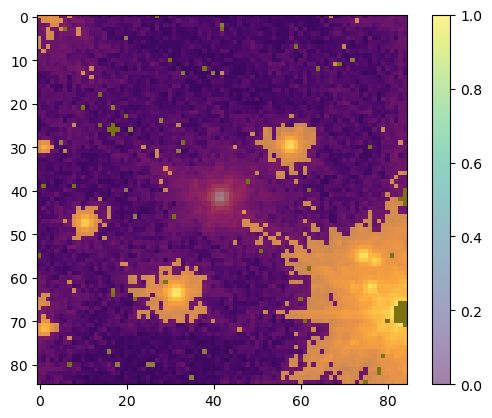

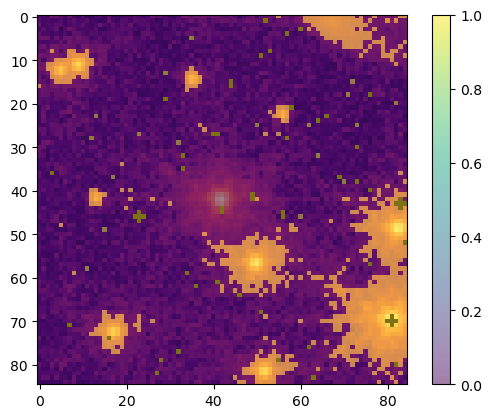

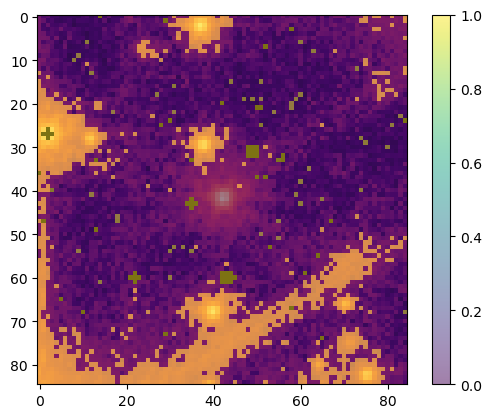

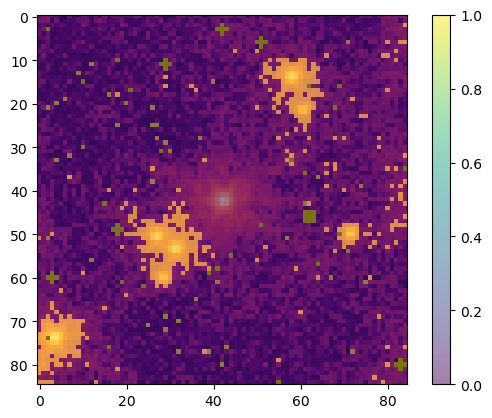

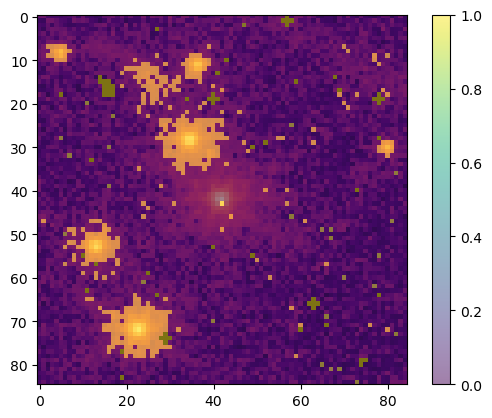

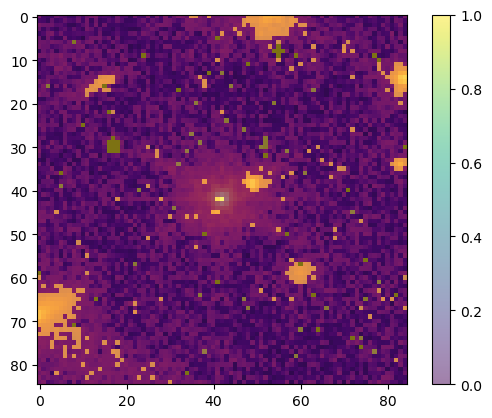

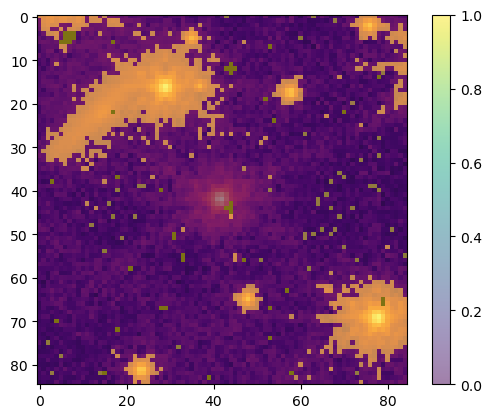

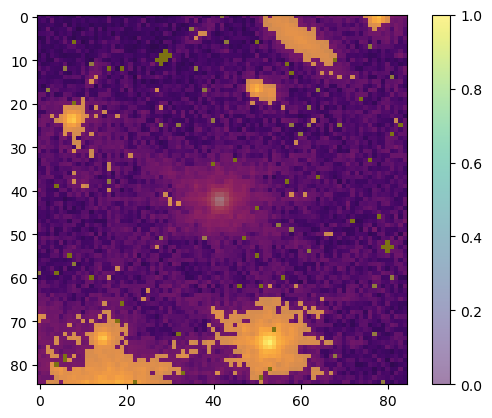

In [67]:
for star_idx in cutouts.get_valid_stars():
    n = np.sum(cutouts.stars[star_idx].cutout)
    plt.imshow(cutouts.stars[star_idx].cutout/n,norm=AsinhNorm(1e-5),cmap="magma")
    plt.imshow(cutouts.stars[star_idx].cutout_weights_rej_builder==0,alpha=0.5)
    plt.colorbar()
    plt.show()